# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.


#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [572]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

base_path = Path('/Users/milenakulik/PycharmProjects/ml-wakacyjne-wyzwanie-2026/01_przetwarzanie_wizualizacja_danych')

## 0. Przygotowanie i rozdzielenie danych

In [573]:
titanic_df = pd.read_csv(base_path / 'titanic.csv')

#zastąpienie kolumn SibSp i Parch kolumną FamilyMemers
titanic_df['Family_Members']=titanic_df['SibSp']+titanic_df['Parch']
titanic_df=titanic_df.drop(columns=['PassengerId', 'Ticket', 'SibSp', 'Parch'])

#zastąpienie kolumny Name kolumną Title
titanic_df['Name']=titanic_df['Name'].str.extract(r',\s([^\.]+)\.')
titanic_df=titanic_df.rename(columns={'Name':'Title'})

#zastąpienie kolumny Cabin kolumną Has_Cabin
titanic_df['Cabin']=titanic_df['Cabin'].notna().astype(int)
titanic_df=titanic_df.rename(columns={'Cabin':'Has_Cabin'})

#utworzenie kolumny IsChild (przypuszczenie: kobiety i dzieci ewakuowane były ze statku jako pierwsze, co zwiększało ich szanse na przeżycie) - muszę to zrobić po uzupełnieniu kolumny Age

#zamiana rzadkich tytułów na Rare
title_counts=titanic_df['Title'].value_counts()
rare_titles=title_counts[title_counts<10].index
titanic_df['Title']=titanic_df['Title'].replace(rare_titles, 'Rare')

#zmiana typów danych
titanic_df['Title']=titanic_df['Title'].astype(object)
titanic_df['Sex']=titanic_df['Sex'].astype(object)
titanic_df['Embarked']=titanic_df['Embarked'].astype(object)

#### Rozdzielenie danych na zbiór treningowy i testowy


Zdecydowałam się uzupełnić brakujące dane po rozdzieleniu danych na zbiór treningowy i testowy, aby uniknąć data leakage.

In [574]:
from sklearn.model_selection import train_test_split

X=titanic_df.drop(columns='Survived')
y=titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1, shuffle=True)

In [575]:
#uzupełnienie brakujących wartości w kolumnie Embarked
X_train['Embarked']=X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])
X_test['Embarked']=X_test['Embarked'].fillna(X_train['Embarked'].mode()[0])

#uzupełnienie brakujących wartości w kolumnie Age
X_train['Age']=X_train['Age'].fillna(X_train.groupby('Title').Age.transform('median'))
age_medians=X_train.groupby('Title')['Age'].median()
X_test['Age']=X_test['Age'].fillna(X_test['Title'].map(age_medians))

#uzupełnienie brakujących wartości w kolumnie Fare
X_train['Fare']=X_train['Fare'].fillna(X_train.groupby('Pclass').Fare.transform('median'))
fare_medians=X_train.groupby('Pclass')['Fare'].median()
X_test['Fare']=X_test['Fare'].fillna(X_test['Pclass'].map(fare_medians))

In [576]:
#kolumna IsChild
X_train['Is_Child']=(X_train['Age']<16).astype(int)
X_test['Is_Child']=(X_test['Age']<16).astype(int)

In [577]:
#kodowanie danych
X_train=pd.get_dummies(data=X_train, prefix='Sex', columns=['Sex'], dtype=int)
X_test=pd.get_dummies(data=X_test, prefix='Sex', columns=['Sex'], dtype=int)

X_train=pd.get_dummies(data=X_train, prefix='Title', columns=['Title'], dtype=int)
X_test=pd.get_dummies(data=X_test, prefix='Title', columns=['Title'], dtype=int)

X_train=pd.get_dummies(data=X_train, prefix='Embarked', columns=['Embarked'], dtype=int)
X_test=pd.get_dummies(data=X_test, prefix='Embarked', columns=['Embarked'], dtype=int)

In [596]:
#sprawdzam, czy w którymś zbiorze nie brakuje jakiejś kolumny
print(set(X_train.columns)==set(X_test.columns))

True


In [598]:
#sprawdzam, czy w obu zbiorach nie ma brakujących danych
print(X_train.isna().sum().sum()==0 and X_test.isna().sum().sum()==0)

True


## 1. Obserwacje z zadania pierwszego
#### Kluczowe predyktory:
- `Sex` - kobiety przeżywały znacznie częściej niż mężczyźni
- `Pclass` oraz `Fare` - pasażerowie 1. klasy oraz osoby z droższymi biletami miały większe szanse na przeżycie
- `Has_Cabin` - pasażerowie, którzy mieli przypisaną kabinę przeżywali częściej
- `Embarked_C` oraz `Embarked_S` - osoby wsiadające w Cherbourg przeżywały częściej niż osoby wsiadające w Southampton

#### Inne obserwacje:
- kolumna `Fare` zawierała wartość znacznie odstającą od innych (ok. 500)

#### Zastosowanie w modelu
W dalszej części zadania staram się zredukować wymiarowość danych poprzez usunięcie kolumn, które nie wnoszą wartości predykcyjnej (pozostawiam kolumny: `Sex_male`, `Sex_female`, `Pclass`, `Fare`, `Has_Cabin`).

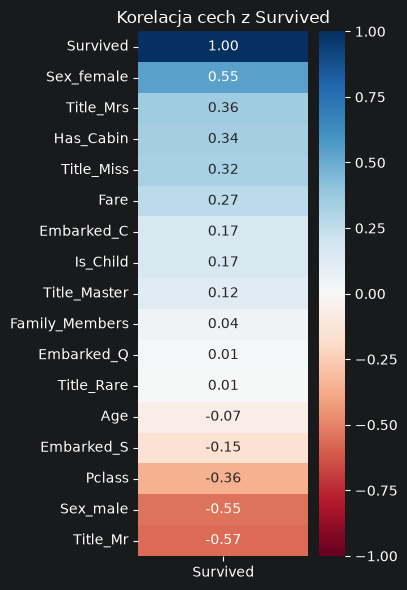

In [580]:
#tworzę dataframe tymczasowo łączącą X_train i y_train, aby zobrazować korelację

train=pd.concat([X_train, y_train], axis=1)

corr_survived=train.corr(numeric_only=True)[['Survived']].sort_values(by='Survived', ascending=False)

plt.figure(figsize=(4, 6))
sns.heatmap(corr_survived, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelacja cech z Survived')
plt.tight_layout()
plt.show()

## 2. Baseline - Dummy Classifier

In [581]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report

model=DummyClassifier(strategy='uniform', random_state=1)

model.fit(X_train, y_train)

y_pred=model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.64      0.51      0.57       106
           1       0.45      0.58      0.50        73

    accuracy                           0.54       179
   macro avg       0.54      0.54      0.53       179
weighted avg       0.56      0.54      0.54       179



array([[54, 52],
       [31, 42]])

## 3. Wybór metryk
Zgodnie ze specyfikacją, predykowana zmienna `Survived` przybiera wartości binarne, więc nie każda metryka będzie nadawała się do oceny jakości modelu.

#### Wybrane przeze mnie metryki:
- **accuracy** - pokazuje, jaki odsetek wszystkich pasażerów model sklasyfikował poprawnie
- **precision** - określa, jaka część obserwacji przypisanych przez model do danej klasy rzeczywiście należy do tej klasy
- **recall** - określa, jaka część wszystkich rzeczywistych obserwacji danej klasy została poprawnie rozpoznana przez model

**Punkt odniesienia:** Klasyfikator bazowy osiąga **54% accuracy**.

## 4. Drzewa decyzyjne

#### Dobór hiperparametrów

In [582]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold

cv_fold=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid={'max_depth': range(1, 10),
    'criterion': ['gini', 'entropy'],
    'min_samples_split': range(2, 10),
    'min_samples_leaf': range(2, 10)}

grid_search=GridSearchCV(estimator=DecisionTreeClassifier(random_state=1), param_grid=param_grid, cv=cv_fold, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

print("Najlepsza kombinacja parametrów:", grid_search.best_params_)
print(f"Najlepszy średni wynik w CV: {round(grid_search.best_score_, 4)}")

best_model=grid_search.best_estimator_
test_acc=best_model.score(X_test, y_test)
print(f"Accuracy na zbiorze testowym: {round(test_acc, 4)}")

Najlepsza kombinacja parametrów: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 2}
Najlepszy średni wynik w CV: 0.8314
Accuracy na zbiorze testowym: 0.7542


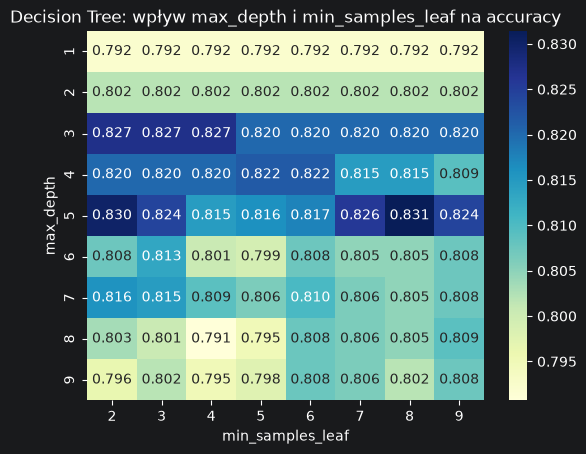

In [583]:
cv_results_tree=pd.DataFrame(grid_search.cv_results_)
pivot_tree=cv_results_tree.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_min_samples_leaf',
    aggfunc='max'
)

sns.heatmap(pivot_tree, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('Decision Tree: wpływ max_depth i min_samples_leaf na accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('max_depth')
plt.show()

#### Uczenie modelu

In [584]:
#wyniki dla zbioru treningowego
y_pred_train=best_model.predict(X_train)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train))
confusion_matrix(y_train, y_pred_train)

#wyniki dla zbioru testowego
y_pred=best_model.predict(X_test)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.83      0.95      0.89       443
           1       0.90      0.69      0.78       269

    accuracy                           0.85       712
   macro avg       0.87      0.82      0.84       712
weighted avg       0.86      0.85      0.85       712

Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.73      0.92      0.82       106
           1       0.82      0.51      0.63        73

    accuracy                           0.75       179
   macro avg       0.78      0.72      0.72       179
weighted avg       0.77      0.75      0.74       179

[[98  8]
 [36 37]]


Znaczna różnica między accuracy na zbiorze treningowym (85%) a testowym (75%) świadczy o przeuczeniu modelu (overfittingu).

Poniżej, bazując na danych przedstawionych na powyższej heatmapie, próbuję ręcznie dobrać parametry w taki sposób, aby zredukować overfitting.

In [585]:
manual_tree=DecisionTreeClassifier(max_depth=3,
                                   min_samples_leaf=7,
                                   min_samples_split=3,
                                   criterion='entropy',
                                   random_state=1)

manual_tree.fit(X_train, y_train)

#wyniki dla zbioru treningowego
y_pred_train=manual_tree.predict(X_train)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

#wyniki dla zbioru testowego
y_pred=manual_tree.predict(X_test)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       443
           1       0.81      0.74      0.77       269

    accuracy                           0.84       712
   macro avg       0.83      0.82      0.82       712
weighted avg       0.83      0.84      0.83       712

[[397  46]
 [ 71 198]]
Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       106
           1       0.81      0.64      0.72        73

    accuracy                           0.79       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.79      0.79       179

[[95 11]
 [26 47]]






Ręczne ograniczenie złożoności modelu (zmniejszenie max_depth) skutecznie zredukowało przeuczenie.
- przed regulacją (parametry wyznaczone przez GridSearchCV): różnica 10 punktów procentowych (85% accuracy dla train oraz 75% dla test)
- po regulacji: różnica 5 punktów procentowych (84% accuracy dla train oraz 79% dla test)

Model osiągnął 79% accuracy. Dla klasy 1 precision wyniosło 81%, a recall 64%. Oznacza to, że model stosunkowo dobrze przewidywał przeżycie, ale pomijał 36% rzeczywistych ocalałych. Model lepiej rozpoznawał ofiary (recall dla klasy 0 wyniósł 90%).

### Ograniczenie kolumn
do `Sex`, `Pclass`, `Fare` oraz `Has_Cabin`

In [586]:
key_features=['Sex_female', 'Sex_male', 'Pclass', 'Fare', 'Has_Cabin']

X_train_sub=X_train[key_features]
X_test_sub=X_test[key_features]

model_sub=DecisionTreeClassifier(max_depth=3,
                                   min_samples_leaf=7,
                                   min_samples_split=2,
                                   criterion='entropy',
                                   random_state=1)

model_sub.fit(X_train_sub, y_train)

#wyniki dla zbioru treningowego:
y_pred_train_sub=model_sub.predict(X_train_sub)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train_sub))
print(confusion_matrix(y_train, y_pred_train_sub))

#wyniki dla zbioru testowego:
y_pred_test_sub=model_sub.predict(X_test_sub)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred_test_sub))
print(confusion_matrix(y_test, y_pred_test_sub))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       443
           1       0.79      0.68      0.73       269

    accuracy                           0.81       712
   macro avg       0.81      0.78      0.79       712
weighted avg       0.81      0.81      0.81       712

[[395  48]
 [ 87 182]]
Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       106
           1       0.79      0.66      0.72        73

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.79      0.78       179

[[93 13]
 [25 48]]


Accuracy pozostało na poziomie 79%. Recall dla klasy 1 wzrósł z 64% do 66%, natomiast precision spadło z 81% do 79%. Model rozpoznał więc nieco więcej rzeczywistych ocalałych, ale kosztem większej liczby błędnych wskazań przeżycia. Ograniczenie cech nie poprawiło ogólnej skuteczności modelu, ale zmieniło rozkład błędów.

## 5. KNN


#### Standaryzacja danych

W przypadku KNN decysuję się na wykonanie standaryzacji danych, ponieważ zmienna `Fare` o dużym zakresie wartości mogłyby zdominować pozostałe predyktory.

Aby uniknąć data leakage, standaryzator został dopasowany wyłącznie do zbioru treningowego.

In [587]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaler.fit(X_train)

X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

#### Dobór hiperparametrów

In [588]:
from sklearn.neighbors import KNeighborsClassifier

param_grid={'n_neighbors': range(1, 17),
    'weights': ['uniform', 'distance'],
    'metric':['euclidean', 'manhattan'],}

grid_search_knn=GridSearchCV(estimator=KNeighborsClassifier(),
                         param_grid=param_grid,
                         cv=cv_fold,
                         scoring='accuracy',
                         n_jobs=-1)

grid_search_knn.fit(X_train_scaled, y_train)

print("Najlepsza kombinacja parametrów:", grid_search_knn.best_params_)
print(f"Najlepszy średni wynik w CV: {round(grid_search_knn.best_score_, 4)}")

best_model_knn=grid_search_knn.best_estimator_
test_acc_knn = best_model_knn.score(X_test_scaled, y_test)
print(f"Accuracy na zbiorze testowym: {round(test_acc_knn, 4)}")

Najlepsza kombinacja parametrów: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'uniform'}
Najlepszy średni wynik w CV: 0.8385
Accuracy na zbiorze testowym: 0.7821


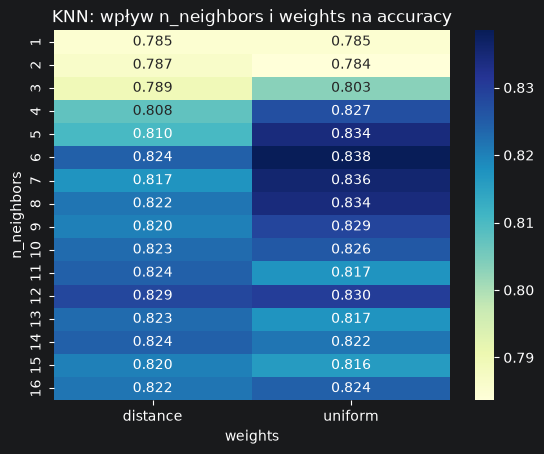

In [589]:
cv_results_knn=pd.DataFrame(grid_search_knn.cv_results_)
pivot_knn=cv_results_knn.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_weights',
    aggfunc='max'
)

sns.heatmap(pivot_knn, annot=True, fmt='.3f', cmap='YlGnBu')
plt.title('KNN: wpływ n_neighbors i weights na accuracy')
plt.xlabel('weights')
plt.ylabel('n_neighbors')
plt.show()

In [590]:
#wyniki dla zbioru treningowego
y_pred_train=best_model_knn.predict(X_train_scaled)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

#wyniki dla zbioru testowego
y_pred=best_model_knn.predict(X_test_scaled)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       443
           1       0.90      0.72      0.80       269

    accuracy                           0.87       712
   macro avg       0.88      0.84      0.85       712
weighted avg       0.87      0.87      0.86       712

[[422  21]
 [ 74 195]]
Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       106
           1       0.84      0.58      0.68        73

    accuracy                           0.78       179
   macro avg       0.80      0.75      0.76       179
weighted avg       0.79      0.78      0.77       179

[[98  8]
 [31 42]]


Znaczna różnica między accuracy na zbiorze treningowym (87%) a testowym (78%) świadczy o przeuczeniu modelu (overfittingu).

Poniżej, bazując na danych przedstawionych na powyższej heatmapie, próbuję ręcznie dobrać parametry w taki sposób, aby zredukować overfitting.

In [599]:
manual_knn=KNeighborsClassifier(n_neighbors=12,
                                weights='uniform',
                                metric='manhattan')

manual_knn.fit(X_train_scaled, y_train)

#wyniki dla zbioru treningowego
y_pred_train=manual_knn.predict(X_train_scaled)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))

#wyniki dla zbioru testowego
y_pred=manual_knn.predict(X_test_scaled)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89       443
           1       0.88      0.71      0.78       269

    accuracy                           0.85       712
   macro avg       0.86      0.82      0.83       712
weighted avg       0.85      0.85      0.85       712

[[416  27]
 [ 79 190]]
Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.78      0.92      0.84       106
           1       0.85      0.62      0.71        73

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.79       179

[[98  8]
 [28 45]]


Ręczne ograniczenie złożoności modelu (zwiększenie n_neighbors) skutecznie zredukowało przeuczenie.
- przed regulacją (parametry wyznaczone przez GridSearchCV): różnica 9 punktów procentowych (87% accuracy dla train oraz 78% dla test)
- po regulacji: różnica 5 punktów procentowych (85% accuracy dla train oraz 80% dla test)

Model osiągnął 80% accuracy. Dla klasy 1 precision wyniosło 85%, a recall 62%. Oznacza to, że model dobrze przewidywał przeżycie, ale rozpoznawał tylko 62% rzeczywistych ocalałych. Model lepiej rozpoznawał ofiary (recall dla klasy 0 wyniósł 92%).

### Ograniczenie kolumn
do `Sex`, `Pclass`, `Fare` oraz `Has_Cabin`

In [592]:
scaler_sub=StandardScaler()

scaler_sub.fit(X_train_sub)

X_train_scaled_sub=scaler_sub.transform(X_train_sub)
X_test_scaled_sub=scaler_sub.transform(X_test_sub)

In [593]:
model_sub=KNeighborsClassifier(n_neighbors=12,
                                weights='uniform',
                                metric='manhattan')

model_sub.fit(X_train_scaled_sub, y_train)

#wyniki dla zbioru treningowego:
y_pred_train_sub=model_sub.predict(X_train_scaled_sub)

print('Wyniki na zbiorze treningowym:')
print(classification_report(y_train, y_pred_train_sub))
print(confusion_matrix(y_train, y_pred_train_sub))

#wyniki dla zbioru testowego:
y_pred_test_sub = model_sub.predict(X_test_scaled_sub)

print('Wyniki na zbiorze testowym:')
print(classification_report(y_test, y_pred_test_sub))
print(confusion_matrix(y_test, y_pred_test_sub))

Wyniki na zbiorze treningowym:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       443
           1       0.82      0.68      0.74       269

    accuracy                           0.82       712
   macro avg       0.82      0.79      0.80       712
weighted avg       0.82      0.82      0.82       712

[[403  40]
 [ 87 182]]
Wyniki na zbiorze testowym:
              precision    recall  f1-score   support

           0       0.75      0.87      0.80       106
           1       0.75      0.58      0.65        73

    accuracy                           0.75       179
   macro avg       0.75      0.72      0.73       179
weighted avg       0.75      0.75      0.74       179

[[92 14]
 [31 42]]


Accuracy spadło z 80% do 75%. Dla klasy 1 zarówno precision, jak i recall spadły - odpowiednio z 85% do 75% oraz z 62% do 58%. Podobnie zachowały się precision i recall dla klasy 0. Model gorzej rozpoznawał więc osoby, które przeżyły. Ograniczenie cech pogorszyło skuteczność KNN, co wskazuje, że usunięte cechy zawierały istotne informacje dla tego modelu.

## 6. Podsumowanie i wnioski końcowe

#### Porównanie z bazowym modelem (baseline):
DummyClassifier osiągnął dokładność na poziomie 54% (dla losowej klasyfikacji). Oba modele osiągnęły znacząco wyższe wyniki (79-80% accuracy na zbiorze testowym).

#### Skuteczność modeli
**K-Nearest Neighbors** osiągnął lepszy wynik pod względem accuracy - 80%, w porównaniu do 79% dla Decision Tree. Dla klasy 1 KNN uzyskał wyższe precision (85% a 81%), co oznacza, że trafniej przewidywał przeżycie. **Decision Tree** osiągnęło natomiast wyższy recall (66% vs 62%), czyli poprawnie rozpoznało większą część rzeczywistych ocalałych.

#### Overfitting
Model wyznaczony przez GridSearchCV osiągnął bardzo dobre wyniki na zbiorze treningowym, ale jego wynik na zbiorze testowym był znacząco niższy. Wskazuje to na przeuczenie modelu (overfitting). Ograniczenie jego złożoności poprzez zmniejszenie `max_depth` oraz zwiększenie `n_neighbors` zmniejszyło różnicę między wynikami i poprawiło wynik na zbiorze testowym.

#### Ograniczenie liczby kolumn
Ograniczenie liczby cech nie wpłynęło znacząco na accuracy Decision Tree, natomiast w przypadku KNN spowodowało spadek accuracy z 80% do 75%. Oznacza to, że dodatkowe cechy były istotne dla KNN. Ograniczenie liczby cech miało większy wpływ na KNN niż na Decision Tree, ponieważ KNN wykorzystuje wszystkie cechy do wyznaczania odległości między obserwacjami. W przypadku drzewa dodatkowe cechy są wykorzystywane tylko wtedy, gdy poprawiają podział danych.